Examen
Nombre:caballero condori franz abdel

1.- Atenúa elruido en la imagen ruido.jpg tal cual se ve en el ejemplo:

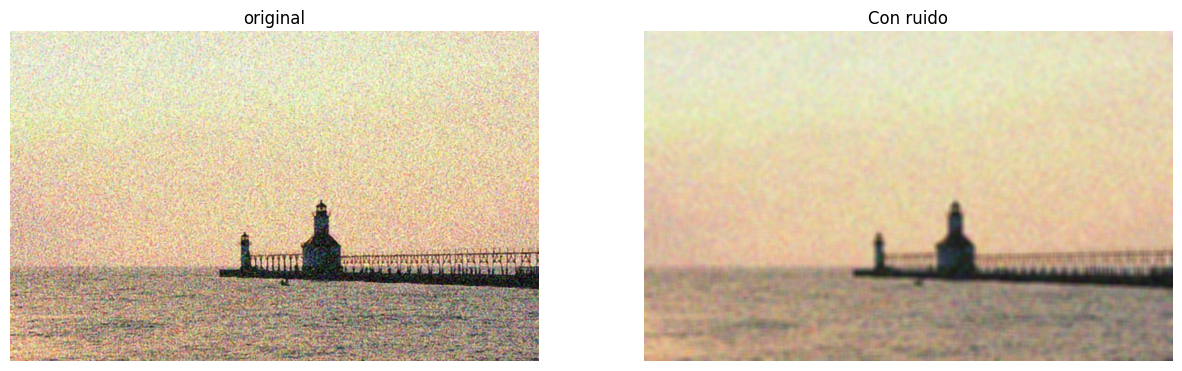

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta=r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\ruido.jpg"

img=cv2.imread(ruta)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGBA)
suavizado=cv2.GaussianBlur(img,(9,9),10)

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.title("original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Con ruido")
plt.imshow(suavizado)
plt.axis("off")

plt.show()


2.- Usando la imagen “rosa.png” obtenga el siguiente resultado:

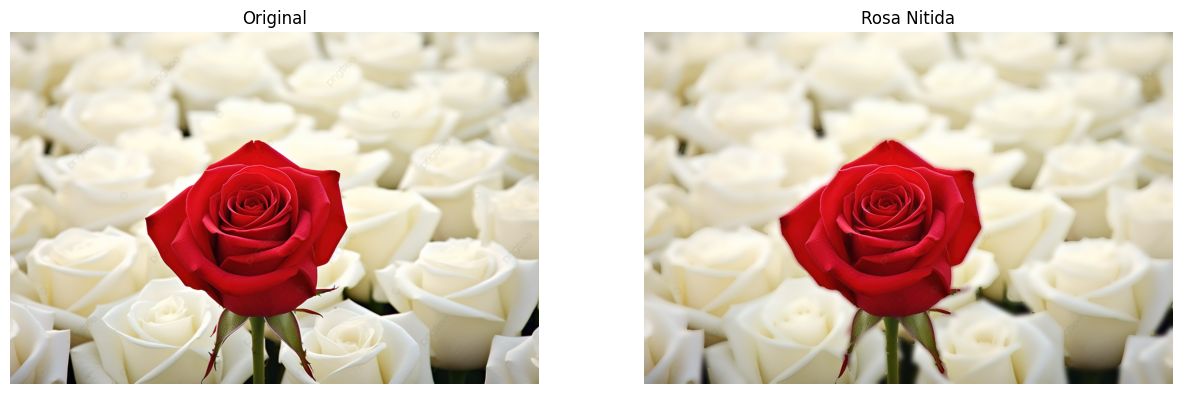

In [133]:

img = cv2.imread(ruta)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

lower = np.array([0, 50, 50]) 
upper = np.array([255, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

blurred = cv2.GaussianBlur(img, (25, 25), 0)

rosa_nitida = cv2.bitwise_and(img, img, mask=mask)
fondo_blur = cv2.bitwise_and(blurred, blurred, mask=cv2.bitwise_not(mask))
resultado = cv2.add(rosa_nitida, fondo_blur)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Rosa Nitida")
plt.imshow(resultado)
plt.axis("off")

plt.show()


3.- Usando la imagen “Elementos jpg” obtenga el siguiente resultado.

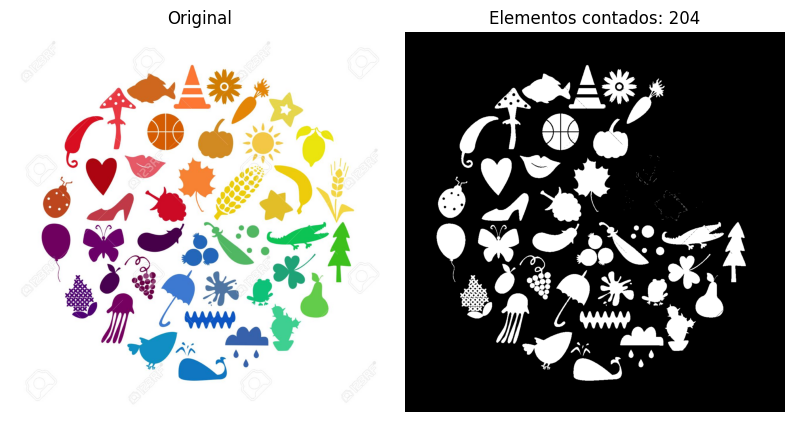

In [125]:


ruta=r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\elementos.jpg"




import cv2
import numpy as np
import matplotlib.pyplot as plt

def conteo(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, imgbin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contornos, _ = cv2.findContours(imgbin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = len(contornos)
    return count, imgbin

imagen = cv2.imread(ruta)

total, binarizada = conteo(imagen)


plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')



plt.subplot(1, 3, 2)
plt.title(f"Elementos contados: {total}")
plt.imshow(cv2.cvtColor(binarizada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


4.- Usando la imagen Cristo obtiene el siguiente resultado (utiliza máscaras de
convolución)

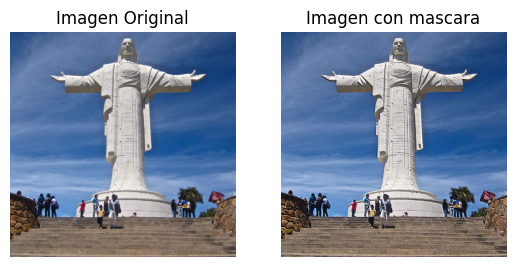

In [183]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\cristo.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
mascara=np.array([[0,-1,0,],
                  [1,1,-1,],
                  [0,1,0,]])
img_final=cv2.filter2D(img,-1,mascara)
plt.subplot(121)
plt.title('Imagen Original')
plt.axis('off')
plt.imshow(img,cmap='gray')

plt.subplot(122)
plt.title('Imagen con mascara')
plt.axis('off')
plt.imshow(img_final,cmap='gray')

plt.show()


5.- Realiza una combinación de técnicas con una fotografía tuya (utiliza las técnicas de
bordes) explica las diferencias

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_18020\4199403363.py:59: RuntimeWarning: invalid value encountered in sqrt
  magnitud=np.sqrt(preX**2+preY**2)


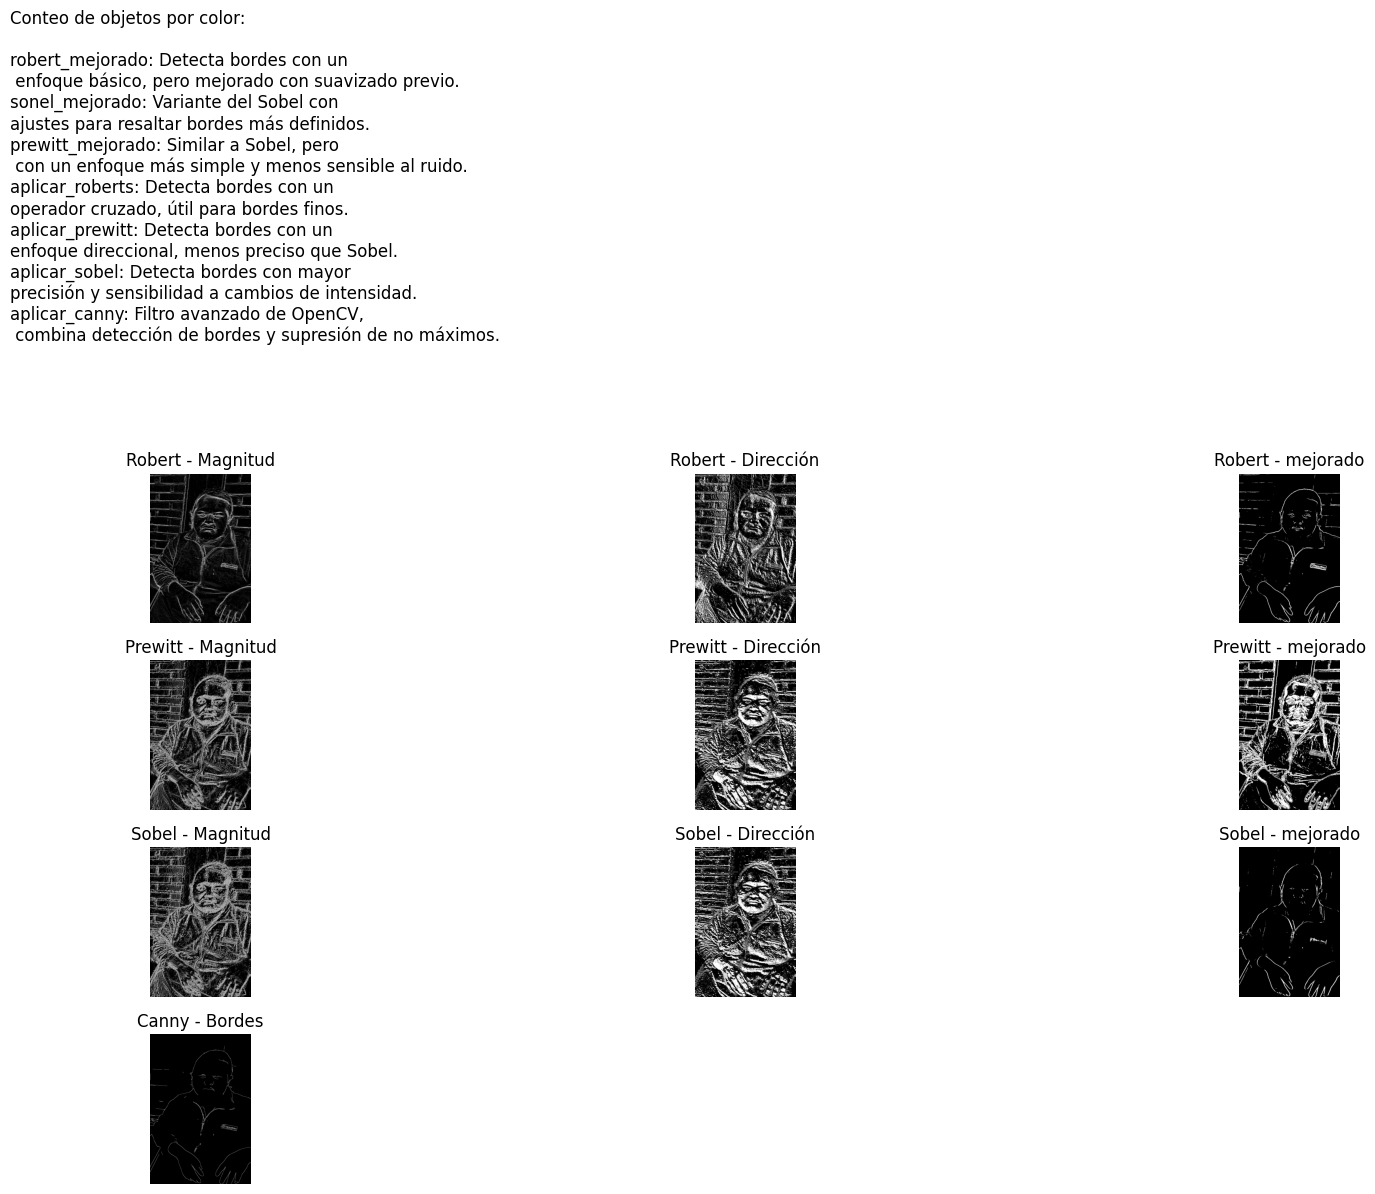

In [ ]:
path = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\img _persona.jpg"

img = cv2.imread(path)
def aplicar_roberts(imagen_gray):
    robertX = np.array([[-1, 0], [0, 1]])
    robertY = np.array([[0, -1], [1, 0]])
    img_RobX = cv2.filter2D(imagen_gray, -1, robertX)
    img_RobY = cv2.filter2D(imagen_gray, -1, robertY)
    magnitud = np.sqrt(img_RobX**2 + img_RobY**2)
    direccion = np.arctan2(img_RobY, img_RobX)
    return magnitud, direccion

def aplicar_prewitt(imagen_gray):
    prewittX = np.array([[1, 0, -1],
                         [1, 0, -1],
                         [1, 0, -1]])
    prewittY = np.array([[1, 1, 1],
                         [0, 0, 0],
                         [-1, -1, -1]])
    img_PrewX = cv2.filter2D(imagen_gray, -1, prewittX)
    img_PrewY = cv2.filter2D(imagen_gray, -1, prewittY)
    magnitud = np.sqrt(img_PrewX**2 + img_PrewY**2)
    direccion = np.arctan2(img_PrewY, img_PrewX)
    return magnitud, direccion

def aplicar_sobel(imagen_gray):
    sobelX = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]])
    sobelY = np.array([[1, 2, 1],
                       [0, 0, 0],
                       [-1, -2, -1]])
    img_SobelX = cv2.filter2D(imagen_gray, -1, sobelX)
    img_SobelY = cv2.filter2D(imagen_gray, -1, sobelY)
    magnitud = np.sqrt(img_SobelX**2 + img_SobelY**2)
    direccion = np.arctan2(img_SobelY, img_SobelX)
    return magnitud, direccion

def aplicar_canny(imagen_gray, t1=100, t2=200):
    return cv2.Canny(imagen_gray, t1, t2)
def robert_mejorado(imagen):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavisado=cv2.GaussianBlur(img_Gray,(3,3),0)
    kernelX=np.array([[-2, 0], [0, 2]],dtype=np.float32)
    kernelY=np.array([[0, 2], [-2, 0]],dtype=np.float32)
    robX=cv2.filter2D(suavisado,cv2.CV_16S,kernelX)
    robY=cv2.filter2D(suavisado,cv2.CV_16S,kernelY)
    robert=cv2.addWeighted(np.abs(robX),0.7,np.abs(robY),0.7,0)
    #resaltar bordes
    _, bordes = cv2.threshold(robert, 30, 255, cv2.THRESH_BINARY)
    return bordes
def prewitt_mejorado(imagen):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_Gray=cv2.GaussianBlur(img_Gray,(3,3),0)
    prewiitX=np.array([[3, 0,-3], [3, 0,-3],[3, 0,-3]],dtype=np.float32)
    prewiitY=np.array([[3, 3,3], [0, 0,0],[-3, -3,-3]],dtype=np.float32)
    preX=cv2.filter2D(img_Gray,cv2.CV_16S,prewiitX)
    preY=cv2.filter2D(img_Gray,cv2.CV_16S,prewiitY)
    magnitud=np.sqrt(preX**2+preY**2)
    #resaltar bordes
    _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
    return bordes
def sonel_mejorado(imagen,tam_kernel=3,umbral=30):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_Gray=cv2.GaussianBlur(img_Gray,(3,3),0)
    sobelX=cv2.Sobel(img_Gray,cv2.CV_64F,1,0,ksize=tam_kernel)
    sobelY=cv2.Sobel(img_Gray,cv2.CV_64F,1,0,ksize=tam_kernel)
    magnitud=np.sqrt(sobelX**2+sobelY**2)
    magnitud=cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #unir bordes
    kernel_morfologico=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_morfologico)
    return bordes
def mostrar_resultados(imagen_path):
    img = cv2.imread(imagen_path)
    if img is None:
        print("No se pudo cargar la imagen.")
        return
    img_Gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes_robert = robert_mejorado(img)
    bordes_sonel = sonel_mejorado(img)
    bordes_prewitt = prewitt_mejorado(img)
    rob_mag, rob_dir = aplicar_roberts(img_Gray)
    prew_mag, prew_dir = aplicar_prewitt(img_Gray)
    sobel_mag, sobel_dir = aplicar_sobel(img_Gray)
    canny = aplicar_canny(img_Gray)

    plt.figure(figsize=(15, 12))
    text = "Conteo de objetos por color:\n\n"
    text += f"robert_mejorado: Detecta bordes con un enfoque básico, pero mejorado con suavizado previo.\n"
    text += f"sonel_mejorado: Variante del Sobel con ajustes para resaltar bordes más definidos.\n"
    text += f"prewitt_mejorado: Similar a Sobel, pero con un enfoque más simple y menos sensible al ruido.\n"
    text += f"aplicar_roberts: Detecta bordes con un operador cruzado, útil para bordes finos.\n"
    text += f"aplicar_prewitt: Detecta bordes con un enfoque direccional, menos preciso que Sobel.\n"
    text += f"aplicar_sobel: Detecta bordes con mayor precisión y sensibilidad a cambios de intensidad.\n"
    text += f"aplicar_canny: Filtro integrado de OpenCV, combina detección de bordes y supresión de no máximos.\n"

    plt.subplot(5, 3, 1)
    plt.text(0, 0.5, text, fontsize=12)
    plt.axis('off')
    # Robert
    plt.subplot(5, 3,4)
    plt.imshow(rob_mag, cmap='gray')
    plt.title("Robert - Magnitud")
    plt.axis('off')

    plt.subplot(5, 3, 5)
    plt.imshow(rob_dir, cmap='gray')
    plt.title("Robert - Dirección")
    plt.axis('off')

    plt.subplot(5, 3, 6)
    plt.imshow(bordes_robert, cmap='gray')
    plt.title("Robert - mejorado")
    plt.axis('off')

    # Prewitt
    plt.subplot(5, 3, 7)
    plt.imshow(prew_mag, cmap='gray')
    plt.title("Prewitt - Magnitud")
    plt.axis('off')

    plt.subplot(5, 3, 8)
    plt.imshow(prew_dir, cmap='gray')
    plt.title("Prewitt - Dirección")
    plt.axis('off')

    plt.subplot(5, 3, 9)
    plt.imshow(bordes_prewitt, cmap='gray')
    plt.title("Prewitt - mejorado")
    plt.axis('off')

    # Sobel
    plt.subplot(5, 3, 10)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title("Sobel - Magnitud")
    plt.axis('off')

    plt.subplot(5, 3, 11)
    plt.imshow(sobel_dir, cmap='gray')
    plt.title("Sobel - Dirección")
    plt.axis('off')

    plt.subplot(5, 3, 12)
    plt.imshow(bordes_sonel, cmap='gray')
    plt.title("Sobel - mejorado")
    plt.axis('off')

    # Canny
    plt.subplot(5, 3, 13)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny - Bordes")
    plt.axis('off')


    

    plt.tight_layout()
    plt.show()
mostrar_resultados(path)


6.- Realiza el código del lapaciano y lapaciano del gausiano mejorando los bordes
(deben verse más nítidos los bordes encontrados )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-32.0..32.0].


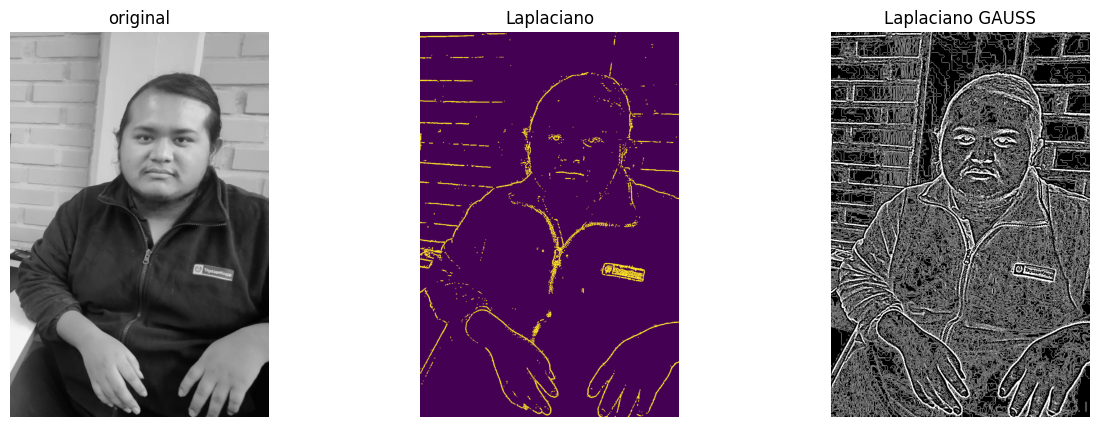

In [163]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta=r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\img _persona.jpg"

img=cv2.imread(ruta,0)
_, imgbin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
ventana=5
factor=6
imagen_umbr=cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,ventana,factor)

img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
laplace = cv2.Laplacian(imagen_umbr, cv2.CV_64F)
laplace = cv2.convertScaleAbs(laplace)


blurred = cv2.GaussianBlur(img, (5, 5), 3)
log = cv2.Laplacian(blurred, cv2.CV_64F)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.title("original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Laplaciano")
plt.imshow(laplace)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Laplaciano GAUSS")
plt.imshow(log)
plt.axis("off")

plt.show()


prueba codigo inge

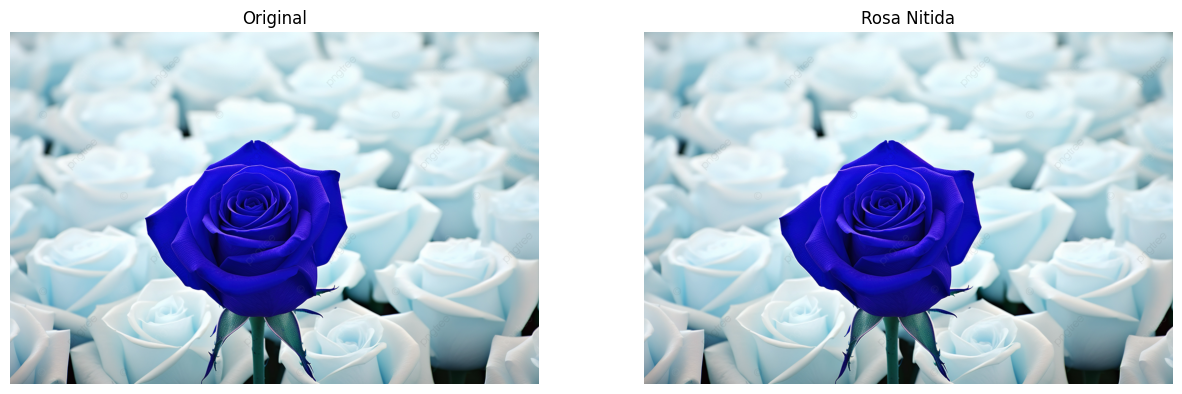

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
def blur(image,mask,kernel):
    blurred = cv2.GaussianBlur(img, (25, 25), 0)
    fin = np.where(mask[:,:,None > 0], image, blurred)

    return fin
ruta=r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\rosa.png"
img = cv2.imread(ruta)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_,mascara=cv2.threshold(gray,100,125,cv2.THRESH_BINARY)
mascara=cv2.bitwise_not(mascara)
mascara=cv2.GaussianBlur(mascara,(9,9),0)
resultado=blur(img,mascara,25)




plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Rosa Nitida")
plt.imshow(resultado)
plt.axis("off")

plt.show()


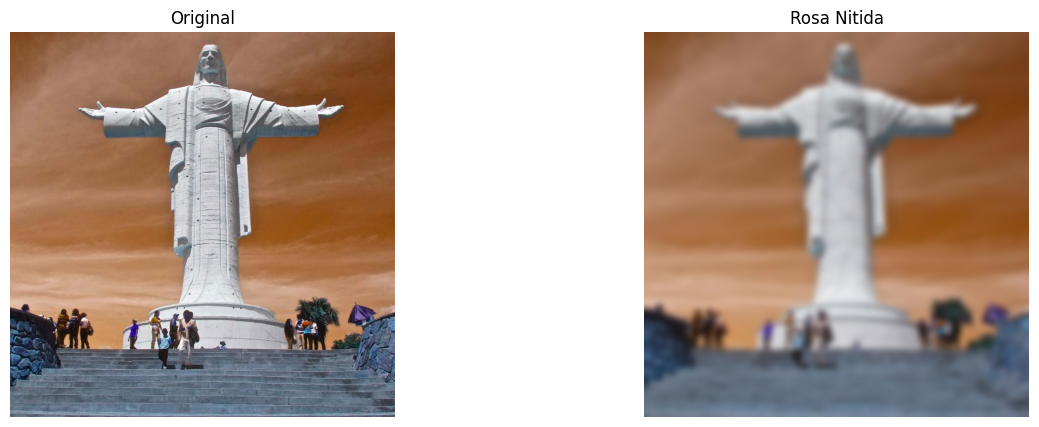

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
def blur(image,mask,kernel):
    blurred = cv2.GaussianBlur(img, (25, 25), 0)
    fin = np.where(mask[:,:,None > 0], image, blurred)

    return fin
ruta=r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\cristo.jpg"
img = cv2.imread(ruta)
imagen_suave=cv2.GaussianBlur(img,(41,41),0)
mascara=np.ones_like(img,dtype=np.float32)
mascara+=0.3

mascara_suave=np.ones_like(img,dtype=np.float32)*0.7
empanisada=(img*0.3)+(imagen_suave*0.7)





plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Rosa Nitida")
plt.imshow(imagen_suave)
plt.axis("off")

plt.show()


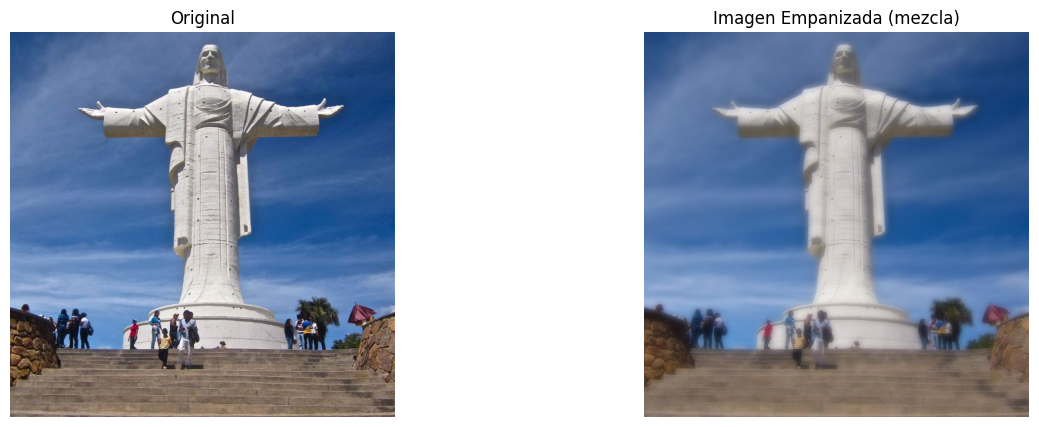

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
ruta = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\examen 2\imagenes\cristo.jpg"
img = cv2.imread(ruta)

# Imagen desenfocada con un kernel grande (desenfoque fuerte)
imagen_suave = cv2.GaussianBlur(img, (41, 41), 0)

# Mezclar ambas imágenes con pesos
empanisada = (img * 0.3 + imagen_suave * 0.7).astype(np.uint8)

# Mostrar resultados en RGB para matplotlib
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Imagen Empanizada (mezcla)")
plt.imshow(cv2.cvtColor(empanisada, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()
